# 05 — Figures for epistasis analysis

This notebook generates figure-ready plots from the processed outputs saved by Notebook 04.

It is parameterized to work for:
- FLU or PULV
- all_x_qtl or ldpruned_x_qtl

Plots are generated from processed locus-level, interval-level, and gene-level summaries rather than raw SNP-level epistasis rows.## 1) Configure figure notebook (choose DRUG + which test outputs to plot)

This notebook will now read **saved outputs from 04A/04B** instead of reading an “annotated epistasis table”.

Saved outputs live under:

- `tables/All vs QTL/<DRUG>/`
- `tables/LDpruned vs QTL/<DRUG>/`

We will load both tests into a dictionary (`DATA`) so downstream plotting cells can:
- plot **All vs QTL** figures
- plot **LDpruned vs QTL** figures
- compare them side-by-side (same plotting functions)

## 1) Configure figure notebook (choose DRUG + which test outputs to plot)

This notebook will now read **saved outputs from 04A/04B** instead of reading an “annotated epistasis table”.

Saved outputs live under:

- `tables/All vs QTL/<DRUG>/`
- `tables/LDpruned vs QTL/<DRUG>/`

We will load both tests into a dictionary (`DATA`) so downstream plotting cells can:
- plot **All vs QTL** figures
- plot **LDpruned vs QTL** figures
- compare them side-by-side (same plotting functions)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# -----------------------
# User parameters
# -----------------------
DRUG = "FLU"                 # change later to "PULV"
RUN_LABEL = "all_x_qtl"      # or "ldpruned_x_qtl"
# -----------------------

VALID_DRUGS = {"FLU", "PULV", "PUL"}
VALID_RUNS = {"all_x_qtl", "ldpruned_x_qtl"}

if DRUG not in VALID_DRUGS:
    raise ValueError(f"DRUG must be one of {VALID_DRUGS}; got {DRUG}")

if RUN_LABEL not in VALID_RUNS:
    raise ValueError(f"RUN_LABEL must be one of {VALID_RUNS}; got {RUN_LABEL}")

if DRUG == "PUL":
    DRUG = "PULV"

drug_code = DRUG.lower()

BASE_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis")
DATA_DIR = BASE_DIR / "data"
PROC_DIR = Path("output/processed_outputs")

# Auto-organized figure directory:
# output/plots/<drug>/<run_label>/
FIG_BASE_DIR = BASE_DIR / "plots"
FIG_DIR = FIG_BASE_DIR / drug_code / RUN_LABEL
FIG_DIR.mkdir(parents=True, exist_ok=True)

PREFIX = f"{drug_code}_{RUN_LABEL}"

print("DRUG:", DRUG)
print("RUN_LABEL:", RUN_LABEL)
print("PREFIX:", PREFIX)
print("PROC_DIR:", PROC_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())

DRUG: FLU
RUN_LABEL: all_x_qtl
PREFIX: flu_all_x_qtl
PROC_DIR: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/output/processed_outputs
FIG_DIR: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/plots/flu/all_x_qtl


In [2]:
FILE_PATHS = {
    "epi_clean": PROC_DIR / f"{PREFIX}_epi_clean.tsv",
    "epi_with_interval": PROC_DIR / f"{PREFIX}_epi_with_interval.tsv",
    "interval_summary": PROC_DIR / f"{PREFIX}_interval_summary.tsv",
    "modifier_snp_summary": PROC_DIR / f"{PREFIX}_modifier_snp_summary.tsv",
    "modifier_snp_annotated": PROC_DIR / f"{PREFIX}_modifier_snp_annotated.tsv",
    "modifier_loci": PROC_DIR / f"{PREFIX}_modifier_loci.tsv",
    "modifier_locus_summary": PROC_DIR / f"{PREFIX}_modifier_locus_summary.tsv",
    "modifier_locus_genes": PROC_DIR / f"{PREFIX}_modifier_locus_genes.tsv",
    "qtl_snp_to_interval": PROC_DIR / f"{PREFIX}_qtl_snp_to_interval.tsv",
    "metadata": PROC_DIR / f"{PREFIX}_metadata.tsv",
}

print("Expected input files:")
for k, v in FILE_PATHS.items():
    print(f"{k}: {v}")

missing_files = [str(path) for path in FILE_PATHS.values() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following processed files are missing:\n" + "\n".join(missing_files)
    )

print("\nAll required processed files are present.")

Expected input files:
epi_clean: output/processed_outputs/flu_all_x_qtl_epi_clean.tsv
epi_with_interval: output/processed_outputs/flu_all_x_qtl_epi_with_interval.tsv
interval_summary: output/processed_outputs/flu_all_x_qtl_interval_summary.tsv
modifier_snp_summary: output/processed_outputs/flu_all_x_qtl_modifier_snp_summary.tsv
modifier_snp_annotated: output/processed_outputs/flu_all_x_qtl_modifier_snp_annotated.tsv
modifier_loci: output/processed_outputs/flu_all_x_qtl_modifier_loci.tsv
modifier_locus_summary: output/processed_outputs/flu_all_x_qtl_modifier_locus_summary.tsv
modifier_locus_genes: output/processed_outputs/flu_all_x_qtl_modifier_locus_genes.tsv
qtl_snp_to_interval: output/processed_outputs/flu_all_x_qtl_qtl_snp_to_interval.tsv
metadata: output/processed_outputs/flu_all_x_qtl_metadata.tsv

All required processed files are present.


In [3]:
missing_files = [str(path) for path in FILE_PATHS.values() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following processed files are missing:\n" + "\n".join(missing_files)
    )

print("All required processed files are present.")

All required processed files are present.


In [4]:
epi_clean = pd.read_csv(FILE_PATHS["epi_clean"], sep="\t")
epi_iv = pd.read_csv(FILE_PATHS["epi_with_interval"], sep="\t")
interval_summary = pd.read_csv(FILE_PATHS["interval_summary"], sep="\t")

mod_summary = pd.read_csv(FILE_PATHS["modifier_snp_summary"], sep="\t")
mod_annot = pd.read_csv(FILE_PATHS["modifier_snp_annotated"], sep="\t")

locus_df = pd.read_csv(FILE_PATHS["modifier_loci"], sep="\t")
locus_summary = pd.read_csv(FILE_PATHS["modifier_locus_summary"], sep="\t")
mod_locus_genes_df = pd.read_csv(FILE_PATHS["modifier_locus_genes"], sep="\t")

map_df = pd.read_csv(FILE_PATHS["qtl_snp_to_interval"], sep="\t")
meta_df = pd.read_csv(FILE_PATHS["metadata"], sep="\t")

print("Loaded tables:")
print("epi_clean:", epi_clean.shape)
print("epi_iv:", epi_iv.shape)
print("interval_summary:", interval_summary.shape)
print("mod_summary:", mod_summary.shape)
print("mod_annot:", mod_annot.shape)
print("locus_df:", locus_df.shape)
print("locus_summary:", locus_summary.shape)
print("mod_locus_genes_df:", mod_locus_genes_df.shape)
print("map_df:", map_df.shape)
print("meta_df:", meta_df.shape)

Loaded tables:
epi_clean: (1296604, 13)
epi_iv: (9366074, 13)
interval_summary: (27, 6)
mod_summary: (4045, 4)
mod_annot: (4045, 7)
locus_df: (15, 7)
locus_summary: (15, 4)
mod_locus_genes_df: (518, 9)
map_df: (9347, 6)
meta_df: (10, 2)


In [5]:
# Ensure numeric types
for df, cols in [
    (locus_summary, ["MOD_LOCUS", "n_interactions", "min_p", "max_beta"]),
    (locus_df, ["MOD_LOCUS", "Chromosome", "Start", "End"]),
    (interval_summary, ["interval_id", "n_interactions", "n_unique_qtl_snps", "n_unique_mod_snps", "min_p", "max_beta"]),
    (epi_iv, ["interval_id", "P", "BETA_INT"]),
    (mod_locus_genes_df, ["MOD_LOCUS", "Chromosome", "Locus_Start", "Locus_End", "n_interactions", "min_p", "max_beta"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
locus_summary["neglog10_min_p"] = -np.log10(locus_summary["min_p"])
interval_summary["neglog10_min_p"] = -np.log10(interval_summary["min_p"])

# Ensure integer-like IDs
locus_summary["MOD_LOCUS"] = locus_summary["MOD_LOCUS"].astype("Int64")
locus_df["MOD_LOCUS"] = locus_df["MOD_LOCUS"].astype("Int64")
mod_locus_genes_df["MOD_LOCUS"] = mod_locus_genes_df["MOD_LOCUS"].astype("Int64")
interval_summary["interval_id"] = interval_summary["interval_id"].astype("Int64")

print("Post-clean check:")
print("locus_summary columns:", locus_summary.columns.tolist())
print("interval_summary columns:", interval_summary.columns.tolist())

display(locus_summary.head())
display(interval_summary.head())

Post-clean check:
locus_summary columns: ['MOD_LOCUS', 'n_interactions', 'min_p', 'max_beta', 'neglog10_min_p']
interval_summary columns: ['interval_id', 'n_interactions', 'n_unique_qtl_snps', 'n_unique_mod_snps', 'min_p', 'max_beta', 'neglog10_min_p']


,MOD_LOCUS,n_interactions,min_p,max_beta,neglog10_min_p
0,9,569006,8.028000e-130,0.032835,129.095393
1,1,151931,1.179000e-106,0.029956,105.928486
2,0,121076,7.735000e-100,0.029101,99.111540
3,12,117797,3.215000e-22,0.013816,21.492819
4,5,116712,9.960000e-30,0.016619,29.001741


,interval_id,n_interactions,n_unique_qtl_snps,n_unique_mod_snps,min_p,max_beta,neglog10_min_p
0,38136,739430,806,1686,1.600000e-36,0.019556,35.79588
1,38135,739430,806,1686,1.600000e-36,0.019556,35.79588
2,38133,739430,806,1686,1.600000e-36,0.019556,35.79588
3,38137,739430,806,1686,1.600000e-36,0.019556,35.79588
4,38140,739430,806,1686,1.600000e-36,0.019556,35.79588


In [8]:
def save_fig(fig, name):
    png = FIG_DIR / f"{PREFIX}_{name}.png"
    pdf = FIG_DIR / f"{PREFIX}_{name}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, dpi=300, bbox_inches="tight")
    print("Saved:", png.name, "and", pdf.name)

def make_locus_label(row):
    locus_id = int(row["MOD_LOCUS"])

    info = locus_df.loc[locus_df["MOD_LOCUS"] == locus_id]

    if info.empty:
        return f"Locus {locus_id}"

    chrom = int(info["Chromosome"].iloc[0])
    start = int(info["Start"].iloc[0])
    end = int(info["End"].iloc[0])

    return f"Chr{chrom}:{start//1000}k–{end//1000}k (L{locus_id})"

def make_interval_label(row):
    return f"Interval {int(row['interval_id'])}"

def show_top(df, sort_col, n=10, ascending=False):
    return df.sort_values(sort_col, ascending=ascending).head(n)

## Figure 1 — Modifier locus ranking by burden and significance

What this plot shows:
- Each point is one modifier locus.
- The x-axis shows how many significant interactions map to that locus.
- The point color shows the strongest epistatic significance observed for that locus as `-log10(min p)`.

How to interpret it:
- Loci farther to the right are broader epistatic hotspots.
- Darker / more intense points are loci with stronger peak epistatic effects.
- This helps distinguish:
  - loci with many interactions
  - loci with fewer but very strong interactions
  - loci that are both broad and strong

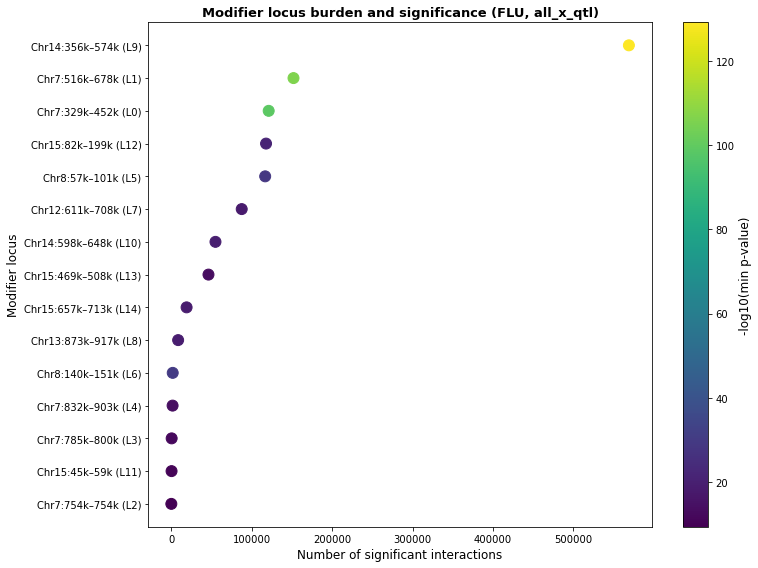

Saved: flu_all_x_qtl_modifier_locus_burden_and_significance.png and flu_all_x_qtl_modifier_locus_burden_and_significance.pdf


In [6]:
plot_df = (
    locus_summary
    .dropna(subset=["MOD_LOCUS", "n_interactions", "min_p"])
    .copy()
)

plot_df["neglog10_min_p"] = -np.log10(plot_df["min_p"])
plot_df["label"] = plot_df.apply(make_locus_label, axis=1)

# rank by interaction burden, then plot top loci
TOP_N_LOCI = min(20, plot_df.shape[0])
plot_df = (
    plot_df.sort_values(["n_interactions", "neglog10_min_p"], ascending=[False, False])
    .head(TOP_N_LOCI)
    .sort_values("n_interactions", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 8))

sc = ax.scatter(
    plot_df["n_interactions"],
    plot_df["label"],
    s=120,
    c=plot_df["neglog10_min_p"]
)

ax.set_xlabel("Number of significant interactions")
ax.set_ylabel("Modifier locus")
ax.set_title(f"Modifier locus burden and significance ({DRUG}, {RUN_LABEL})")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(min p-value)")

plt.tight_layout()
plt.show()

save_fig(fig, "modifier_locus_burden_and_significance")

## Figure 2— Chromosome-pair interaction counts

What this plot shows:
- Each tile represents the number of significant epistatic interactions between a QTL-side chromosome and a modifier-side chromosome.

How to interpret it:
- Brighter tiles indicate chromosome pairs that contribute many significant interactions.
- This helps identify broad cross-chromosomal interaction structure before zooming into specific loci or genes.
- It is a coarse summary, so it is best used as a context panel rather than as final biological resolution.

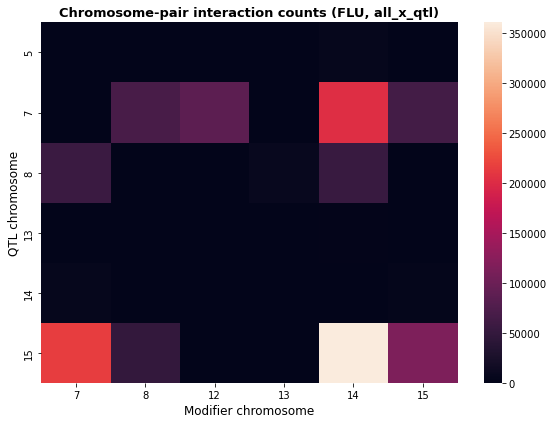

Saved: flu_all_x_qtl_chromosome_pair_interaction_counts.png and flu_all_x_qtl_chromosome_pair_interaction_counts.pdf


In [8]:
# Build QTL-chromosome and modifier-chromosome columns from epi_clean
required_cols = {"CHR1", "CHR2", "SNP1_is_qtl", "SNP2_is_qtl"}
missing = required_cols - set(epi_clean.columns)
if missing:
    raise ValueError(f"epi_clean is missing required columns for chromosome-pair heatmap: {missing}")

chrpair_df = epi_clean.copy()

chrpair_df["QTL_CHR"] = np.where(chrpair_df["SNP1_is_qtl"], chrpair_df["CHR1"], chrpair_df["CHR2"])
chrpair_df["MOD_CHR"] = np.where(chrpair_df["SNP1_is_qtl"], chrpair_df["CHR2"], chrpair_df["CHR1"])

chrpair_summary = (
    chrpair_df.groupby(["QTL_CHR", "MOD_CHR"])
    .size()
    .reset_index(name="n_interactions")
)

heat = chrpair_summary.pivot(
    index="QTL_CHR",
    columns="MOD_CHR",
    values="n_interactions"
).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat, ax=ax)
ax.set_xlabel("Modifier Chromosome")
ax.set_ylabel("QTL Chromosome")
ax.set_title(f"Number of interactions between Chromosomes")
plt.tight_layout()
plt.show()

save_fig(fig, "chromosome_pair_interaction_counts")

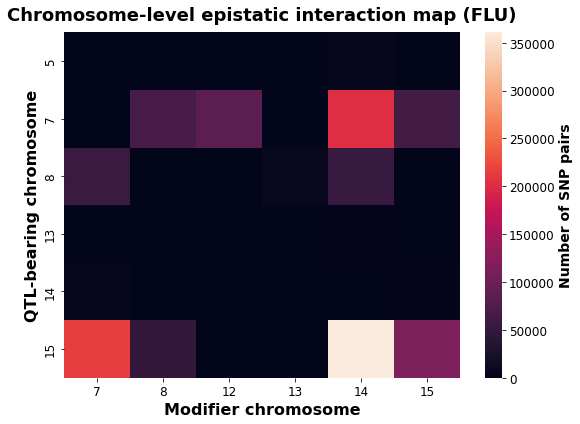

Saved: flu_all_x_qtl_chromosome_pair_interaction_counts.png and flu_all_x_qtl_chromosome_pair_interaction_counts.pdf


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

hm = sns.heatmap(
    heat,
    ax=ax,
    cmap="rocket",
    cbar_kws={"label": "Number of SNP pairs"}
)

ax.set_xlabel("Modifier chromosome", fontsize=16, fontweight="bold")
ax.set_ylabel("QTL-bearing chromosome", fontsize=16, fontweight="bold")
ax.set_title(
    "Chromosome-level epistatic interaction map (FLU)",
    fontsize=18,
    fontweight="bold",
    pad=12
)

ax.tick_params(axis="both", labelsize=12)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Number of SNP pairs", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

save_fig(fig, "chromosome_pair_interaction_counts")

## Figure 3 — Modifier loci across the genome with candidate gene labels

What this plot shows:
- Each point is one modifier locus.
- The x-axis is the genomic midpoint of the locus.
- The y-axis is the modifier chromosome.
- Point size reflects the number of significant interactions.
- Point color reflects the strongest interaction significance.
- Labels show a representative overlapping gene for each locus.

How to interpret it:
- This plot combines genomic position, locus strength, and a candidate gene label.
- It is useful for quickly identifying which broad modifier regions may correspond to interpretable genes.
- Labels are representative and do not imply that only that gene is involved.

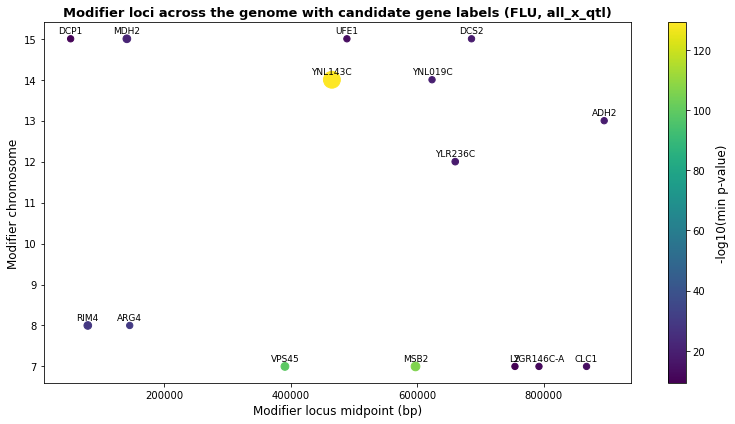

Saved: flu_all_x_qtl_modifier_loci_genome_scatter_with_gene_labels.png and flu_all_x_qtl_modifier_loci_genome_scatter_with_gene_labels.pdf


In [11]:
# Build one representative gene label per modifier locus
# Preference: gene_standard_name / Standard_name if available, otherwise gene_name

gene_label_col = None
for c in ["Standard_name", "gene_standard_name", "gene_name"]:
    if c in mod_locus_genes_df.columns:
        gene_label_col = c
        break

if gene_label_col is None:
    raise ValueError("No usable gene name column found in mod_locus_genes_df")

rep_gene_df = (
    mod_locus_genes_df
    .dropna(subset=["MOD_LOCUS", gene_label_col])
    .sort_values(["MOD_LOCUS", "min_p"], ascending=[True, True])
    .groupby("MOD_LOCUS", as_index=False)
    .first()[["MOD_LOCUS", gene_label_col]]
    .rename(columns={gene_label_col: "rep_gene"})
)

plot_df = (
    locus_df[["MOD_LOCUS", "Chromosome", "Start", "End"]]
    .merge(
        locus_summary[["MOD_LOCUS", "n_interactions", "min_p"]],
        on="MOD_LOCUS",
        how="left"
    )
    .merge(
        rep_gene_df,
        on="MOD_LOCUS",
        how="left"
    )
    .dropna(subset=["MOD_LOCUS", "Chromosome", "n_interactions"])
    .copy()
)

plot_df["mid_bp"] = (plot_df["Start"] + plot_df["End"]) / 2
plot_df["neglog10_min_p"] = -np.log10(plot_df["min_p"])

fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(
    plot_df["mid_bp"],
    plot_df["Chromosome"],
    s=np.clip(plot_df["n_interactions"] / 2000, 40, 300),
    c=plot_df["neglog10_min_p"]
)

# Add representative gene labels
for _, row in plot_df.iterrows():
    label = row["rep_gene"] if pd.notna(row["rep_gene"]) else f"L{int(row['MOD_LOCUS'])}"
    ax.text(
        row["mid_bp"],
        row["Chromosome"] + 0.08,
        str(label),
        fontsize=9,
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Modifier locus midpoint (bp)")
ax.set_ylabel("Modifier chromosome")
ax.set_title(f"Modifier loci across the genome with candidate gene labels ({DRUG}, {RUN_LABEL})")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(min p-value)")

plt.tight_layout()
plt.show()

save_fig(fig, "modifier_loci_genome_scatter_with_gene_labels")

## Figure 4— Top QTL intervals by epistatic burden

What this plot shows:
- Each bar is a QTL interval on the anchor side of the epistasis scan.
- The bar length shows how many significant interactions map to that interval.

How to interpret it:
- Longer bars indicate QTL intervals that participate in more epistatic interactions.
- These intervals are strong candidates for follow-up because they connect broadly to modifier loci.
- If interval gene annotations are available, labels help link interval burden back to candidate genes.

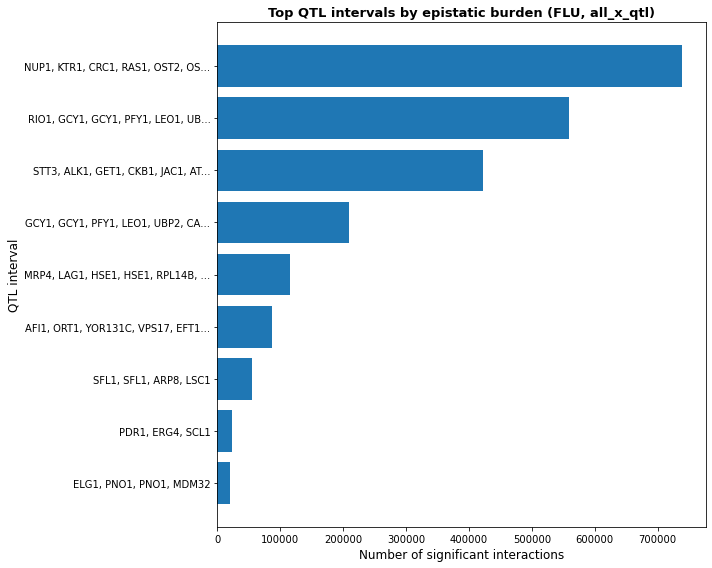

Saved: flu_all_x_qtl_top_qtl_intervals_by_epistatic_burden.png and flu_all_x_qtl_top_qtl_intervals_by_epistatic_burden.pdf


In [10]:
# Load QTL interval table for interval labels
# Update filenames here if your saved QTL tables use different names.

if DRUG == "FLU":
    QTL_RESULTS_FILE = DATA_DIR / "Fluconazole_QTL_genes_20260312.csv"
elif DRUG == "PULV":
    QTL_RESULTS_FILE = DATA_DIR / "Pulvinatal_QTL_genes_20260330.csv"
else:
    raise ValueError(f"Unsupported DRUG: {DRUG}")

qtl_df = pd.read_csv(QTL_RESULTS_FILE)

required_cols = {"interval_id"}
missing = required_cols - set(qtl_df.columns)
if missing:
    raise ValueError(f"QTL table missing required columns: {missing}")

# Pick a label column if available
interval_label_col = None
for c in ["genes_std", "gene_standard_name", "genes", "gene_name"]:
    if c in qtl_df.columns:
        interval_label_col = c
        break

label_df = qtl_df[["interval_id"]].drop_duplicates().copy()

if interval_label_col is not None:
    label_df["interval_label"] = (
        qtl_df.groupby("interval_id")[interval_label_col]
        .first()
        .reindex(label_df["interval_id"])
        .values
    )
else:
    label_df["interval_label"] = label_df["interval_id"].apply(lambda x: f"Interval {int(x)}")

plot_df = (
    interval_summary
    .merge(label_df, on="interval_id", how="left")
    .dropna(subset=["interval_id", "n_interactions"])
    .sort_values("n_interactions", ascending=False)
    .head(20)
    .copy()
)

def shorten_label(x):
    x = str(x)
    if len(x) > 35:
        return x[:32] + "..."
    return x

plot_df["label"] = plot_df["interval_label"].fillna(
    plot_df["interval_id"].apply(lambda x: f"Interval {int(x)}")
).apply(shorten_label)

plot_df = plot_df.sort_values("n_interactions", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["label"], plot_df["n_interactions"])
ax.set_xlabel("Number of significant interactions")
ax.set_ylabel("QTL interval")
ax.set_title(f"Top QTL intervals by epistatic burden ({DRUG}, {RUN_LABEL})")
plt.tight_layout()
plt.show()

save_fig(fig, "top_qtl_intervals_by_epistatic_burden")

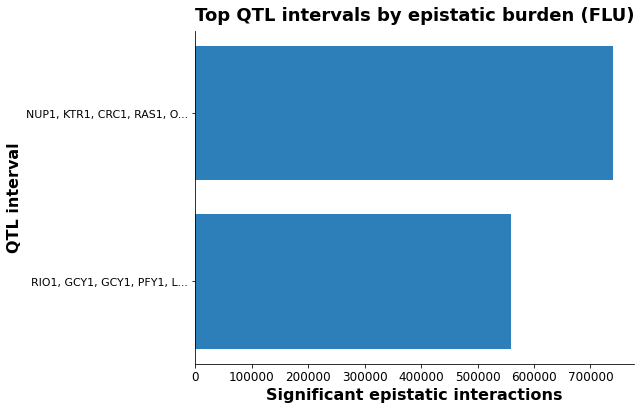

Saved: flu_all_x_qtl_top_qtl_intervals_by_epistatic_burden.png and flu_all_x_qtl_top_qtl_intervals_by_epistatic_burden.pdf


In [12]:
# Load QTL interval table for interval labels
if DRUG == "FLU":
    QTL_RESULTS_FILE = DATA_DIR / "Fluconazole_QTL_genes_20260312.csv"
elif DRUG == "PULV":
    QTL_RESULTS_FILE = DATA_DIR / "Pulvinatal_QTL_genes_20260330.csv"
else:
    raise ValueError(f"Unsupported DRUG: {DRUG}")

qtl_df = pd.read_csv(QTL_RESULTS_FILE)

required_cols = {"interval_id"}
missing = required_cols - set(qtl_df.columns)
if missing:
    raise ValueError(f"QTL table missing required columns: {missing}")

# Pick a label column if available
interval_label_col = None
for c in ["genes_std", "gene_standard_name", "genes", "gene_name"]:
    if c in qtl_df.columns:
        interval_label_col = c
        break

label_df = qtl_df[["interval_id"]].drop_duplicates().copy()

if interval_label_col is not None:
    label_df["interval_label"] = (
        qtl_df.groupby("interval_id")[interval_label_col]
        .first()
        .reindex(label_df["interval_id"])
        .values
    )
else:
    label_df["interval_label"] = label_df["interval_id"].apply(lambda x: f"Interval {int(x)}")

plot_df = (
    interval_summary
    .merge(label_df, on="interval_id", how="left")
    .dropna(subset=["interval_id", "n_interactions"])
    .sort_values("n_interactions", ascending=False)
    .head(10)   # better for poster
    .copy()
)

def shorten_label(x, max_len=28):
    x = str(x)
    if len(x) > max_len:
        return x[:max_len - 3] + "..."
    return x

plot_df["label"] = plot_df["interval_label"].fillna(
    plot_df["interval_id"].apply(lambda x: f"Interval {int(x)}")
).apply(shorten_label)

# Sort so the largest bar is at the top in the horizontal barplot
plot_df = plot_df.sort_values("n_interactions", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.8))

ax.barh(
    plot_df["label"],
    plot_df["n_interactions"],
    color="#2C7FB8"
)

ax.set_xlabel("Significant epistatic interactions", fontsize=16, fontweight="bold")
ax.set_ylabel("QTL interval", fontsize=16, fontweight="bold")
ax.set_title(
    "Top QTL intervals by epistatic burden (FLU)",
    fontsize=18,
    fontweight="bold",
    pad=10
)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

# Clean up spines for poster-style appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

save_fig(fig, "top_qtl_intervals_by_epistatic_burden")

## Figure — QTL interval × modifier locus heatmap with gene labels

What this plot shows:
- Rows are QTL intervals labeled by their interval-level gene annotation.
- Columns are modifier loci labeled by genomic position.
- Tile intensity reflects the number of significant interactions, shown on a log scale.

How to interpret it:
- Bright cells mark dominant QTL interval–modifier locus pairs.
- Vertical stripes indicate modifier loci that interact with many QTL intervals.
- Horizontal stripes indicate QTL intervals with broad epistatic burden.
- Gene labels make the interval-side of the heatmap biologically interpretable.

Saved: flu_all_x_qtl_gene_by_modifier_locus_heatmap.png and flu_all_x_qtl_gene_by_modifier_locus_heatmap.pdf


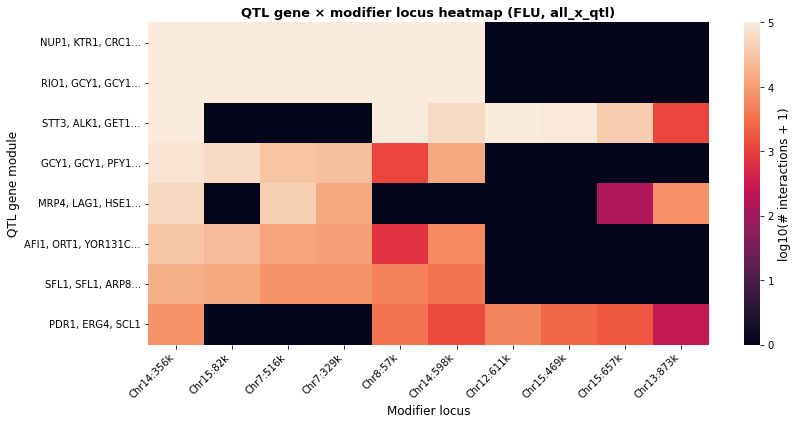

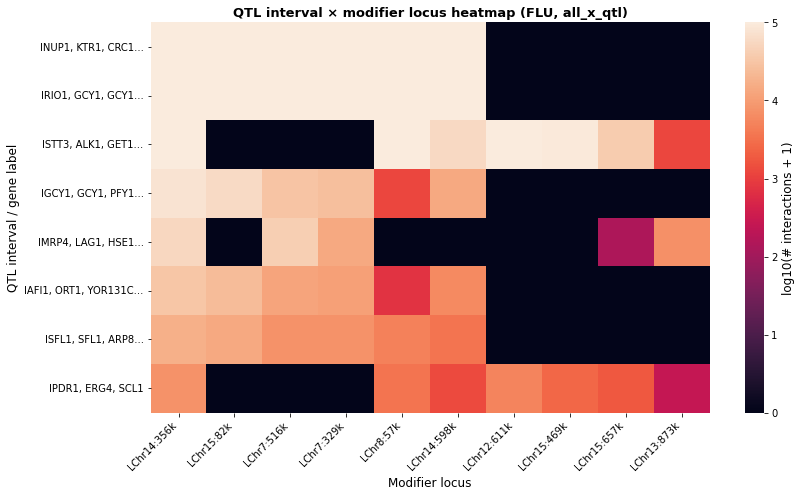

Saved: flu_all_x_qtl_interval_by_modifier_locus_heatmap_clean.png and flu_all_x_qtl_interval_by_modifier_locus_heatmap_clean.pdf


In [30]:
# Load QTL interval annotation table for row labels
if DRUG == "FLU":
    QTL_RESULTS_FILE = DATA_DIR / "Fluconazole_QTL_genes_20260312.csv"
elif DRUG == "PULV":
    QTL_RESULTS_FILE = DATA_DIR / "Pulvinatal_QTL_genes_20260330.csv"
else:
    raise ValueError(f"Unsupported DRUG: {DRUG}")

qtl_df = pd.read_csv(QTL_RESULTS_FILE)

if "interval_id" not in qtl_df.columns:
    raise ValueError("QTL results file must contain 'interval_id'")

# Choose best label column
interval_label_col = None
for c in ["genes_std", "genes", "gene_standard_name", "gene_name"]:
    if c in qtl_df.columns:
        interval_label_col = c
        break

if interval_label_col is None:
    raise ValueError("No usable gene label column found in qtl_df")

def clean_interval_label(x):
    x = str(x)
    if x.strip() == "" or x.lower() == "nan":
        return "Unannotated"
    genes = [g.strip() for g in x.split(",") if g.strip()]
    if len(genes) == 0:
        return "Unannotated"
    return ", ".join(genes[:3]) + ("..." if len(genes) > 3 else "")

# Force exactly one label per interval
interval_label_df = (
    qtl_df.groupby("interval_id")[interval_label_col]
    .first()
    .reset_index()
)
interval_label_df["interval_label"] = interval_label_df[interval_label_col].apply(clean_interval_label)
interval_label_map = dict(zip(interval_label_df["interval_id"], interval_label_df["interval_label"]))

# Modifier locus labels
locus_label_map = {
    int(r["MOD_LOCUS"]): f"Chr{int(r['Chromosome'])}:{int(r['Start'])//1000}k"
    for _, r in locus_df.iterrows()
}

# Ensure heat_summary exists
if "heat_summary" not in globals():
    raise ValueError("heat_summary missing")

# Collapse strictly to one row per (interval, locus)
heat_summary_collapsed = (
    heat_summary
    .groupby(["interval_id", "MOD_LOCUS"], as_index=False)["n_interactions"]
    .sum()
)

# ---------- Collapse to gene-level instead of interval_id ----------

# Map interval_id → gene label
heat_summary_collapsed["interval_label"] = heat_summary_collapsed["interval_id"].map(interval_label_map)

# Aggregate interactions at gene-level
gene_heat = (
    heat_summary_collapsed
    .groupby(["interval_label", "MOD_LOCUS"], as_index=False)
    .agg(n_interactions=("n_interactions", "sum"))
)

# Build matrix
mat = gene_heat.pivot(
    index="interval_label",
    columns="MOD_LOCUS",
    values="n_interactions"
).fillna(0)

# Order rows/columns by total interaction strength
row_order = mat.sum(axis=1).sort_values(ascending=False).index
col_order = mat.sum(axis=0).sort_values(ascending=False).index

mat = mat.loc[row_order, col_order]

# Limit to top signals (clean figure)
TOP_ROWS = 8
TOP_COLS = 10
mat = mat.iloc[:TOP_ROWS, :TOP_COLS]

# Apply locus labels
mat.columns = [locus_label_map.get(i, f"L{i}") for i in mat.columns]

# Log scale
mat_log = np.log10(mat + 1)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    mat_log,
    ax=ax,
    vmin=0,
    vmax=5,
    cbar_kws={"label": "log10(# interactions + 1)"}
)

ax.set_xlabel("Modifier locus")
ax.set_ylabel("QTL gene module")
ax.set_title(f"QTL gene × modifier locus heatmap ({DRUG}, {RUN_LABEL})")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_fig(fig, "gene_by_modifier_locus_heatmap")
# Order rows/cols by total burden
row_order = mat.sum(axis=1).sort_values(ascending=False).index
col_order = mat.sum(axis=0).sort_values(ascending=False).index

mat = mat.loc[row_order, col_order]

# Limit size for readability
TOP_INTERVALS = 12
TOP_LOCI = 10
mat = mat.iloc[:TOP_INTERVALS, :TOP_LOCI]

# Apply labels AFTER slicing
mat.index = [interval_label_map.get(i, f"I{i}") for i in mat.index]
mat.columns = [locus_label_map.get(i, f"L{i}") for i in mat.columns]

# Log scale
mat_log = np.log10(mat + 1)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    mat_log,
    ax=ax,
    vmin=0,
    vmax=5,
    cbar_kws={"label": "log10(# interactions + 1)"}
)

ax.set_xlabel("Modifier locus")
ax.set_ylabel("QTL interval / gene label")
ax.set_title(f"QTL interval × modifier locus heatmap ({DRUG}, {RUN_LABEL})")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

save_fig(fig, "interval_by_modifier_locus_heatmap_clean")

## Figure — Gene interaction network with QTL LOD and pleiotropy encoding

What this plot shows:
- Blue-to-red QTL-side nodes are colored by pleiotropy score.
- QTL-side node size reflects QTL strength (`lod_max`).
- Modifier-side node size reflects how many significant interactions map to that modifier gene.
- Edge width reflects interaction burden between the QTL gene/module and modifier gene.

How to interpret it:
- Large QTL nodes indicate stronger anchor intervals.
- More intensely colored QTL nodes indicate higher pleiotropy.
- Large modifier nodes indicate broader modifier hubs.
- Thick edges highlight dominant gene–gene interaction modules.

Edges retained: 46


,qtl_gene_simple,modifier_gene,n_interactions
64,STT3,YNL143C,345994
62,STT3,YLR236C,173792
60,STT3,RIM4,134726
61,STT3,UFE1,91546
18,GCY1,YNL143C,78112
13,GCY1,MDH2,59382
63,STT3,YNL019C,57452
59,STT3,DCS2,37626
5,AFI1,YNL143C,31874
14,GCY1,MSB2,29700


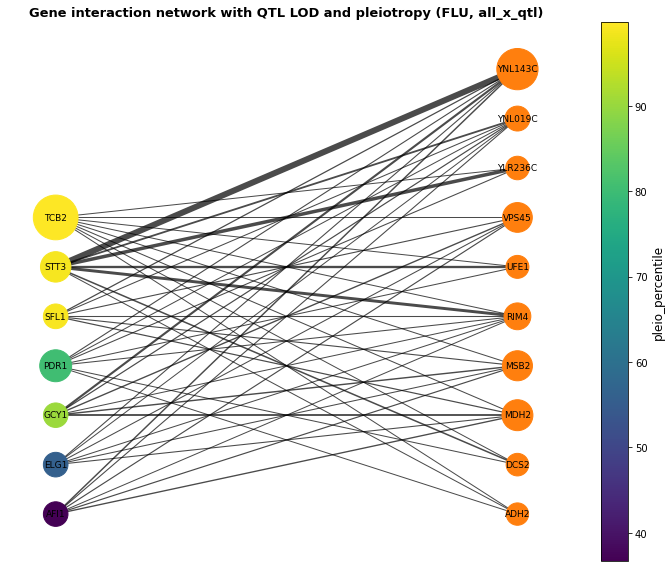

Saved: flu_all_x_qtl_gene_gene_network_lod_pleio.png and flu_all_x_qtl_gene_gene_network_lod_pleio.pdf


In [36]:
import networkx as nx
import matplotlib as mpl

# ---------- Helper ----------
def simplify_label(x):
    x = str(x)
    genes = [g.strip() for g in x.split(",") if g.strip()]
    if len(genes) == 0:
        return "Unknown"
    return genes[0]

# ---------- Representative modifier gene per locus ----------
gene_label_col = None
for c in ["Standard_name", "gene_standard_name", "gene_name"]:
    if c in mod_locus_genes_df.columns:
        gene_label_col = c
        break

if gene_label_col is None:
    raise ValueError("No usable gene label column found in mod_locus_genes_df")

rep_gene_df = (
    mod_locus_genes_df
    .dropna(subset=["MOD_LOCUS", gene_label_col])
    .sort_values(["MOD_LOCUS", "min_p"], ascending=[True, True])
    .groupby("MOD_LOCUS", as_index=False)
    .first()[["MOD_LOCUS", gene_label_col]]
    .rename(columns={gene_label_col: "modifier_gene"})
)

# ---------- QTL interval annotation ----------
if DRUG == "FLU":
    QTL_RESULTS_FILE = DATA_DIR / "Fluconazole_QTL_genes_20260312.csv"
elif DRUG == "PULV":
    QTL_RESULTS_FILE = DATA_DIR / "Pulvinatal_QTL_genes_20260330.csv"
else:
    raise ValueError(f"Unsupported DRUG: {DRUG}")

qtl_df = pd.read_csv(QTL_RESULTS_FILE)

required_cols = {"interval_id", "lod_max"}
missing = required_cols - set(qtl_df.columns)
if missing:
    raise ValueError(f"QTL table missing required columns: {missing}")

# Choose pleiotropy column if available
pleio_col = None
for c in ["pleio_percentile", "pleio_score"]:
    if c in qtl_df.columns:
        pleio_col = c
        break

if pleio_col is None:
    raise ValueError("QTL table must contain pleio_percentile or pleio_score")

# Choose interval label column
interval_label_col = None
for c in ["genes_std", "genes", "gene_standard_name", "gene_name"]:
    if c in qtl_df.columns:
        interval_label_col = c
        break

if interval_label_col is None:
    raise ValueError("No usable gene label column found in qtl_df")

# One label + metrics per interval
interval_info = (
    qtl_df
    .groupby("interval_id", as_index=False)
    .agg({
        interval_label_col: "first",
        "lod_max": "max",
        pleio_col: "max"
    })
)

interval_info["qtl_gene_simple"] = interval_info[interval_label_col].apply(simplify_label)

# ---------- Build interval × modifier locus summary ----------
if "heat_summary_collapsed" not in globals():
    raise ValueError("heat_summary_collapsed not found. Run the heatmap summary cell first.")

edge_df = heat_summary_collapsed.copy()

edge_df = edge_df.merge(
    interval_info[["interval_id", "qtl_gene_simple", "lod_max", pleio_col]],
    on="interval_id",
    how="left"
)

edge_df = edge_df.merge(
    rep_gene_df,
    on="MOD_LOCUS",
    how="left"
)

edge_df = edge_df.dropna(subset=["qtl_gene_simple", "modifier_gene"])

# Collapse to gene-module × modifier-gene edges
gene_edge_df = (
    edge_df
    .groupby(["qtl_gene_simple", "modifier_gene"], as_index=False)
    .agg(
        n_interactions=("n_interactions", "sum")
    )
)

# QTL node metrics aggregated from contributing intervals
qtl_node_df = (
    interval_info
    .groupby("qtl_gene_simple", as_index=False)
    .agg(
        lod_max=("lod_max", "max"),
        pleio_value=(pleio_col, "max")
    )
)

# Modifier node metrics
modifier_node_df = (
    gene_edge_df
    .groupby("modifier_gene", as_index=False)
    .agg(
        total_interactions=("n_interactions", "sum")
    )
)

# ---------- Select nodes instead of edges ----------
TOP_QTL_GENES = 8
TOP_MOD_GENES = 10

# Top QTL genes by LOD (or use interaction burden if you prefer)
top_qtl_genes = (
    qtl_node_df
    .sort_values("lod_max", ascending=False)
    .head(TOP_QTL_GENES)["qtl_gene_simple"]
    .tolist()
)

# Top modifier genes by interaction burden
top_mod_genes = (
    modifier_node_df
    .sort_values("total_interactions", ascending=False)
    .head(TOP_MOD_GENES)["modifier_gene"]
    .tolist()
)

# Keep edges only among selected nodes
plot_df = gene_edge_df[
    gene_edge_df["qtl_gene_simple"].isin(top_qtl_genes) &
    gene_edge_df["modifier_gene"].isin(top_mod_genes)
].copy()

print("Edges retained:", plot_df.shape[0])
display(plot_df.sort_values("n_interactions", ascending=False).head(20))

# ---------- Build graph ----------
G = nx.Graph()

# Add QTL nodes
for _, row in qtl_node_df.iterrows():
    G.add_node(
        row["qtl_gene_simple"],
        bipartite=0,
        lod_max=row["lod_max"],
        pleio_value=row["pleio_value"]
    )

# Add modifier nodes
for _, row in modifier_node_df.iterrows():
    G.add_node(
        row["modifier_gene"],
        bipartite=1,
        total_interactions=row["total_interactions"]
    )

# Add edges
for _, row in plot_df.iterrows():
    G.add_edge(
        row["qtl_gene_simple"],
        row["modifier_gene"],
        weight=row["n_interactions"]
    )

# Keep only nodes participating in plotted edges
nodes_in_edges = set()
for u, v in G.edges():
    nodes_in_edges.add(u)
    nodes_in_edges.add(v)
G = G.subgraph(nodes_in_edges).copy()

# ---------- Bipartite layout ----------
qtl_nodes = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 0]
mod_nodes = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 1]

pos = {}
for i, n in enumerate(sorted(qtl_nodes)):
    pos[n] = (-1, i)
for i, n in enumerate(sorted(mod_nodes)):
    pos[n] = (1, i)

# ---------- Node sizes ----------
qtl_lod = np.array([G.nodes[n].get("lod_max", 0) for n in qtl_nodes], dtype=float)
if len(qtl_lod) > 0:
    qtl_sizes = 600 + 1400 * (qtl_lod - qtl_lod.min()) / (qtl_lod.max() - qtl_lod.min() + 1e-9)
else:
    qtl_sizes = []

mod_burden = np.array([G.nodes[n].get("total_interactions", 0) for n in mod_nodes], dtype=float)
if len(mod_burden) > 0:
    mod_sizes = 500 + 1200 * (mod_burden - mod_burden.min()) / (mod_burden.max() - mod_burden.min() + 1e-9)
else:
    mod_sizes = []

# ---------- QTL node colors by pleiotropy ----------
qtl_pleio = np.array([G.nodes[n].get("pleio_value", 0) for n in qtl_nodes], dtype=float)
norm = mpl.colors.Normalize(vmin=qtl_pleio.min(), vmax=qtl_pleio.max() + 1e-9)
cmap = plt.cm.viridis
qtl_colors = cmap(norm(qtl_pleio))

# Modifier nodes in fixed color
modifier_color = "tab:orange"

# ---------- Edge widths ----------
weights = np.array([G[u][v]["weight"] for u, v in G.edges()], dtype=float)
edge_widths = 1 + 5 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)

# ---------- Draw ----------
fig, ax = plt.subplots(figsize=(10, 8))

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.7)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=qtl_nodes,
    node_color=qtl_colors,
    node_size=qtl_sizes,
    ax=ax,
    label="QTL genes"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=mod_nodes,
    node_color=modifier_color,
    node_size=mod_sizes,
    ax=ax,
    label="Modifier genes"
)

nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

# Colorbar for pleiotropy
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(pleio_col)

ax.set_title(f"Gene interaction network with QTL LOD and pleiotropy ({DRUG}, {RUN_LABEL})")
ax.axis("off")

plt.tight_layout()
plt.show()

save_fig(fig, "gene_gene_network_lod_pleio")

In [ ]:
a